# 06 Difference Maps and Comparison Grids

This notebook generates visual diagnostics for the OpenCV Telea restoration baseline.

It creates:

1. full-image difference maps,
2. masked-region-only difference maps,
3. comparison grids showing clean, mask, masked input, restored output, and error map.

The maps produced here use local normalization. This makes each map readable, but it does **not** make color intensity directly comparable across cases.

In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src


In [8]:
import pandas as pd

from restoration_eval.paths import (
    CLEAN_DIR,
    MASK_DIR,
    MASKED_DIR,
    METRICS_DIR,
    FIGURES_DIR,
    PROCESSED_METADATA_DIR,
    RESTORED_DIR,
)

from restoration_eval.error_maps import (
    create_difference_maps,
    create_comparison_grids,
)

## 1. Load restoration metadata

In [9]:
RESTORATION_METADATA_PATH = PROCESSED_METADATA_DIR / "metadata_restorations_opencv_telea.csv"

restoration_metadata = pd.read_csv(RESTORATION_METADATA_PATH)
restoration_metadata.columns = restoration_metadata.columns.str.strip()

display(restoration_metadata)
print("Rows:", len(restoration_metadata))

,painting_id,mask_type,model_name,inpaint_radius,clean_filename,mask_filename,masked_filename,restored_filename,mask_area_ratio
0,p001,irregular_small,opencv_telea,3,p001_clean.png,p001_irregular_small_mask.png,p001_irregular_small_masked.png,p001_irregular_small_restored_opencv_telea.png,0.0254
1,p001,scratch_lines,opencv_telea,3,p001_clean.png,p001_scratch_lines_mask.png,p001_scratch_lines_masked.png,p001_scratch_lines_restored_opencv_telea.png,0.0233
2,p001,irregular_large,opencv_telea,3,p001_clean.png,p001_irregular_large_mask.png,p001_irregular_large_masked.png,p001_irregular_large_restored_opencv_telea.png,0.1134
3,p002,irregular_small,opencv_telea,3,p002_clean.png,p002_irregular_small_mask.png,p002_irregular_small_masked.png,p002_irregular_small_restored_opencv_telea.png,0.0274
4,p002,scratch_lines,opencv_telea,3,p002_clean.png,p002_scratch_lines_mask.png,p002_scratch_lines_masked.png,p002_scratch_lines_restored_opencv_telea.png,0.0243
5,p002,irregular_large,opencv_telea,3,p002_clean.png,p002_irregular_large_mask.png,p002_irregular_large_masked.png,p002_irregular_large_restored_opencv_telea.png,0.1129
6,p003,irregular_small,opencv_telea,3,p003_clean.png,p003_irregular_small_mask.png,p003_irregular_small_masked.png,p003_irregular_small_restored_opencv_telea.png,0.0254
7,p003,scratch_lines,opencv_telea,3,p003_clean.png,p003_scratch_lines_mask.png,p003_scratch_lines_masked.png,p003_scratch_lines_restored_opencv_telea.png,0.0158
8,p003,irregular_large,opencv_telea,3,p003_clean.png,p003_irregular_large_mask.png,p003_irregular_large_masked.png,p003_irregular_large_restored_opencv_telea.png,0.1112


Rows: 9


## 2. Generate difference maps

In [10]:
DIFF_MAP_DIR = FIGURES_DIR / "difference_maps"
DIFF_METADATA_PATH = METRICS_DIR / "difference_map_summary_opencv_telea.csv"

diff_metadata = create_difference_maps(
    restoration_metadata=restoration_metadata,
    clean_dir=CLEAN_DIR,
    mask_dir=MASK_DIR,
    restored_dir=RESTORED_DIR / "opencv_telea",
    diff_map_dir=DIFF_MAP_DIR,
)

diff_metadata.to_csv(DIFF_METADATA_PATH, index=False)

display(diff_metadata)
print("Saved:", DIFF_METADATA_PATH)
print("Difference map directory:", DIFF_MAP_DIR)

,painting_id,mask_type,model_name,diff_filename,diff_masked_filename,max_abs_diff,mean_abs_diff_full,mean_abs_diff_masked
0,p001,irregular_small,opencv_telea,p001_irregular_small_opencv_telea_diff.png,p001_irregular_small_opencv_telea_diff_masked_...,32.000000,0.119746,4.714594
1,p001,scratch_lines,opencv_telea,p001_scratch_lines_opencv_telea_diff.png,p001_scratch_lines_opencv_telea_diff_masked_on...,94.333336,0.112400,4.823983
2,p001,irregular_large,opencv_telea,p001_irregular_large_opencv_telea_diff.png,p001_irregular_large_opencv_telea_diff_masked_...,101.333336,1.414233,12.476045
3,p002,irregular_small,opencv_telea,p002_irregular_small_opencv_telea_diff.png,p002_irregular_small_opencv_telea_diff_masked_...,43.666668,0.197944,7.235070
4,p002,scratch_lines,opencv_telea,p002_scratch_lines_opencv_telea_diff.png,p002_scratch_lines_opencv_telea_diff_masked_on...,147.333328,0.168409,6.940446
5,p002,irregular_large,opencv_telea,p002_irregular_large_opencv_telea_diff.png,p002_irregular_large_opencv_telea_diff_masked_...,52.666668,0.999594,8.857144
6,p003,irregular_small,opencv_telea,p003_irregular_small_opencv_telea_diff.png,p003_irregular_small_opencv_telea_diff_masked_...,74.000000,0.375600,14.768215
7,p003,scratch_lines,opencv_telea,p003_scratch_lines_opencv_telea_diff.png,p003_scratch_lines_opencv_telea_diff_masked_on...,84.333336,0.102845,6.505827
8,p003,irregular_large,opencv_telea,p003_irregular_large_opencv_telea_diff.png,p003_irregular_large_opencv_telea_diff_masked_...,89.000000,2.292114,20.611731


Saved: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\difference_map_summary_opencv_telea.csv
Difference map directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\difference_maps


## 3. Generate comparison grids

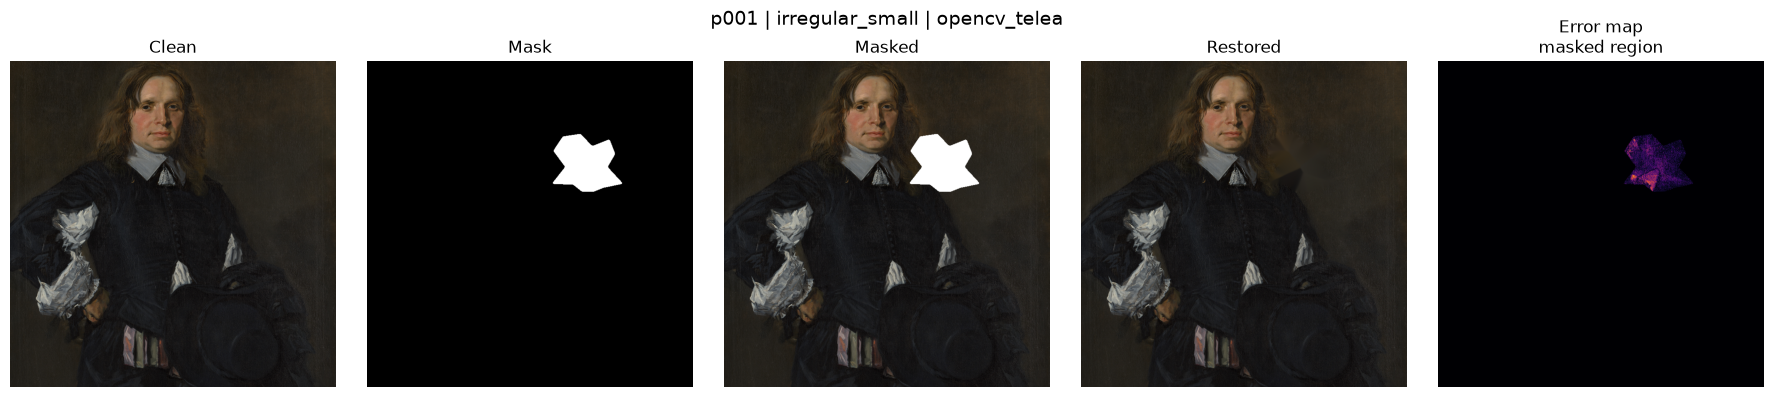

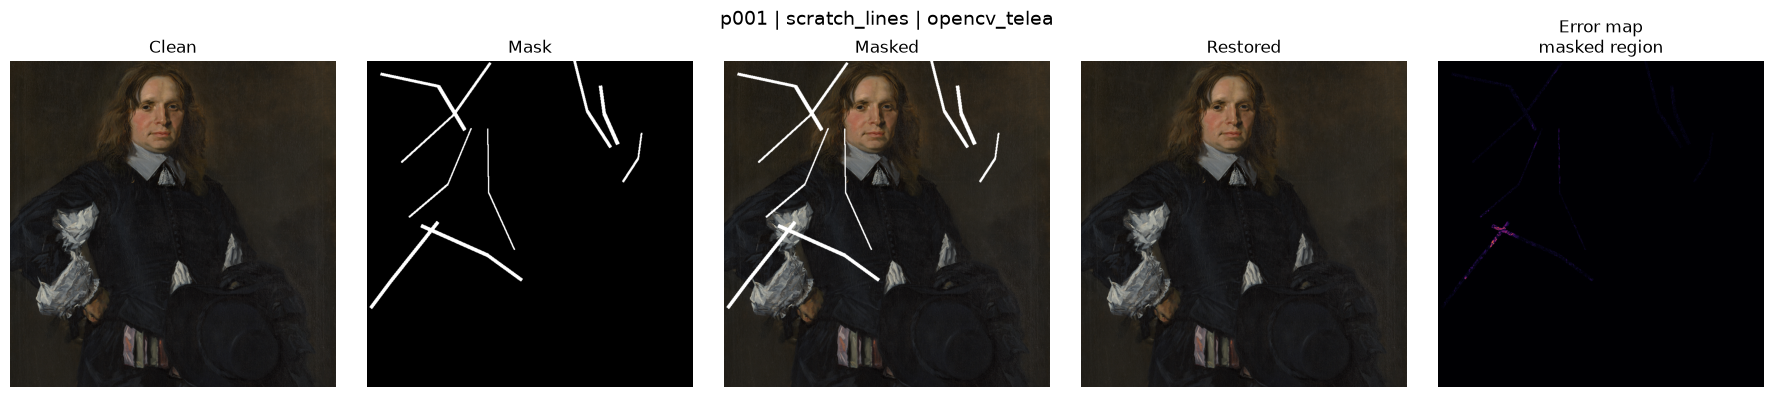

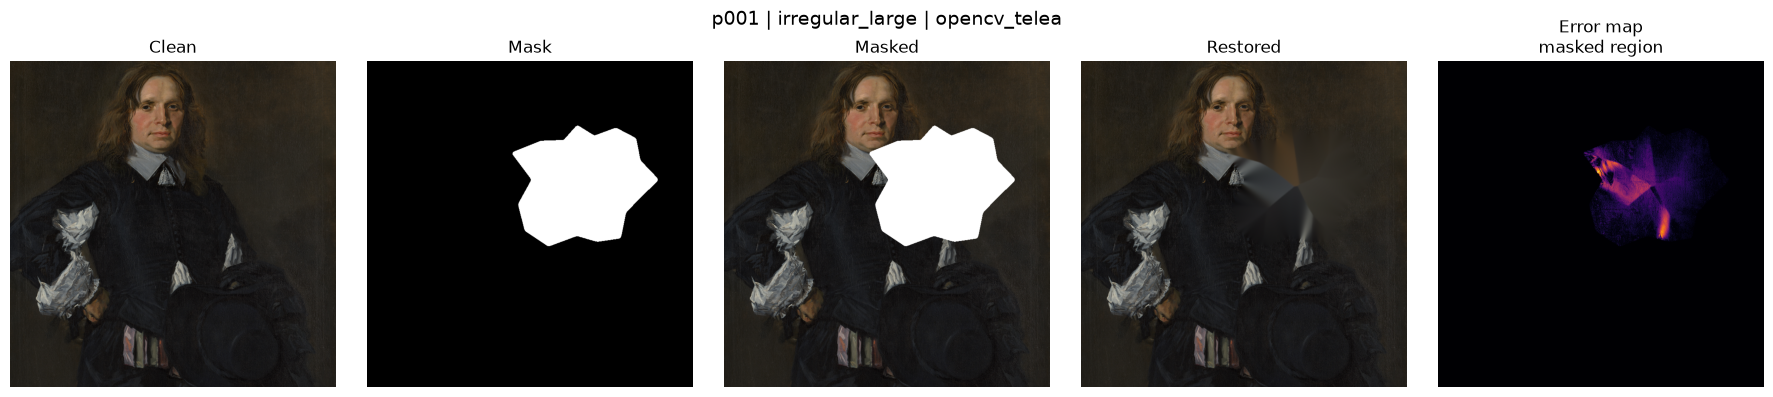

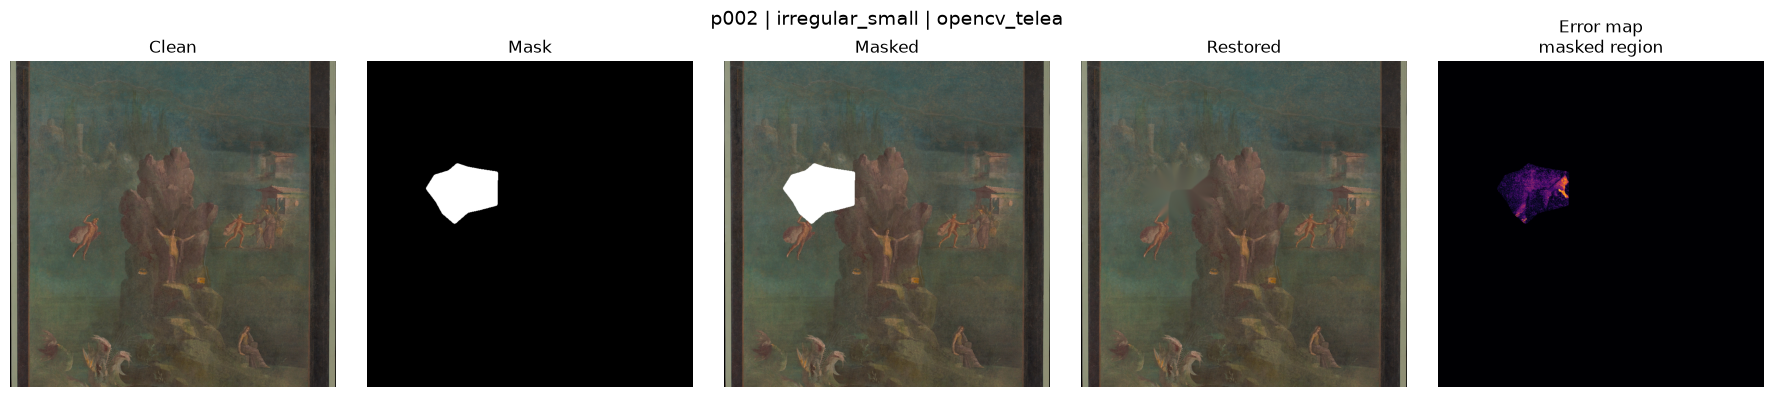

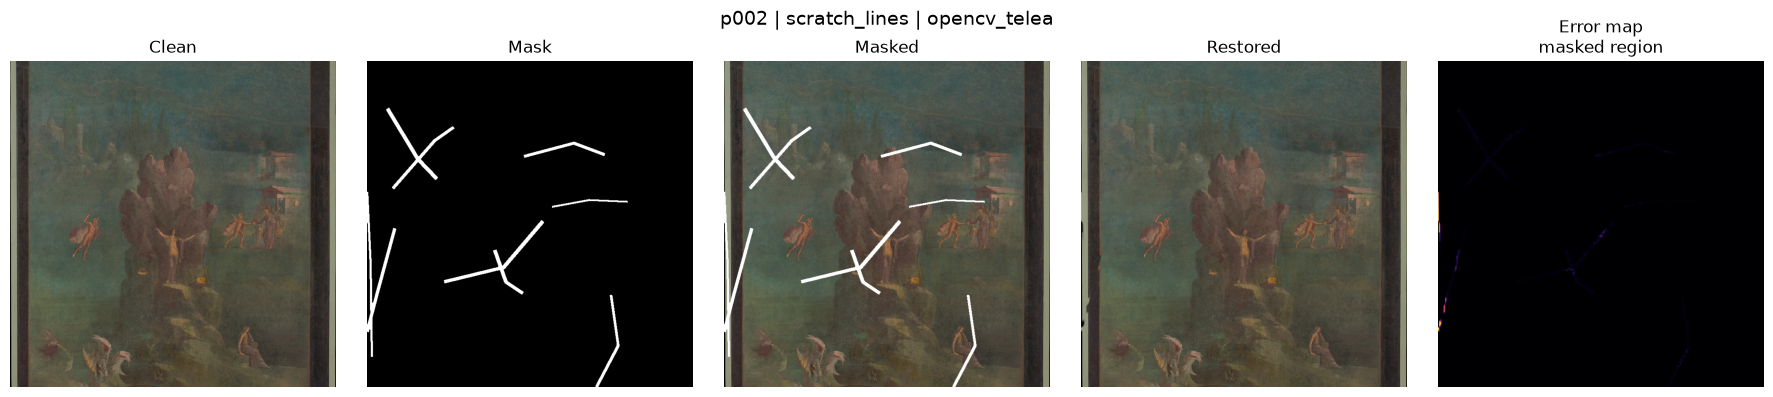

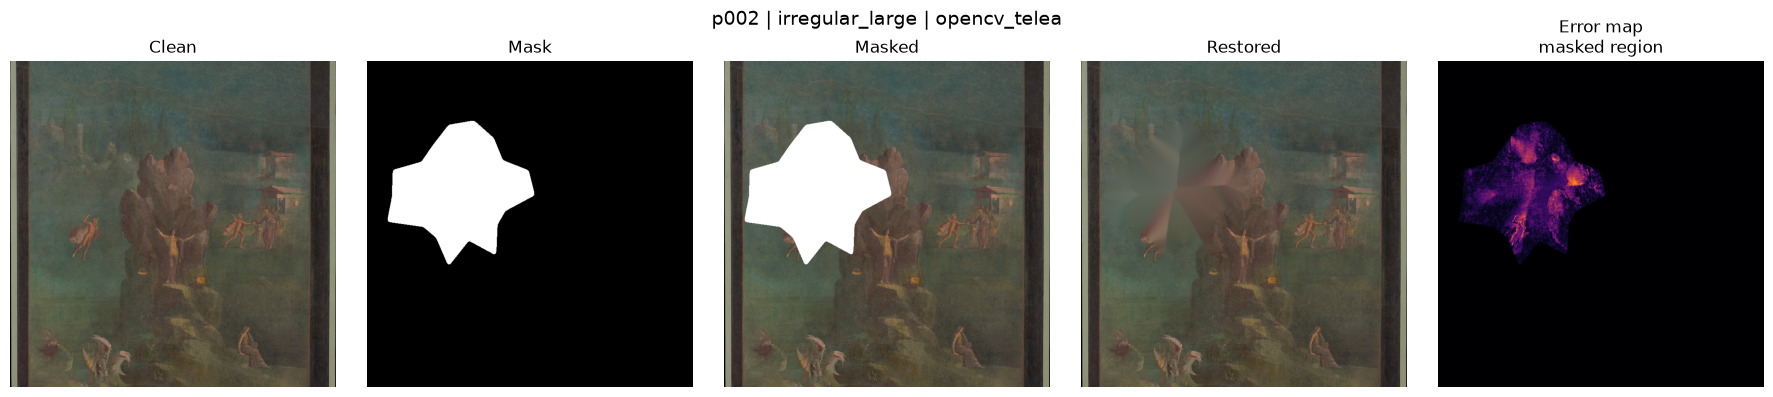

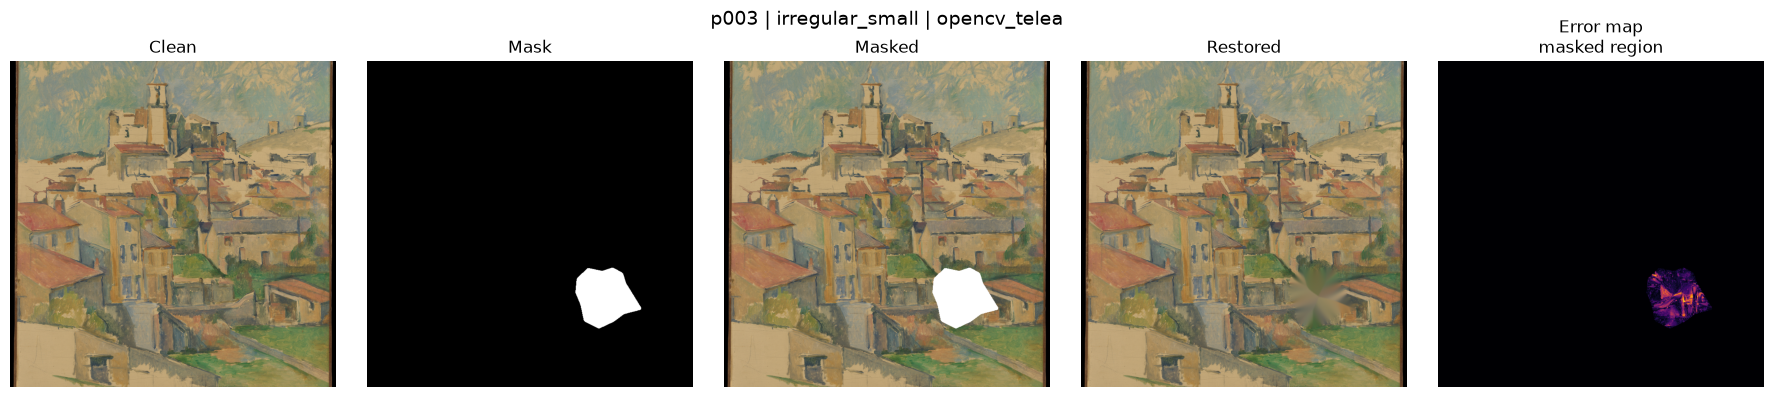

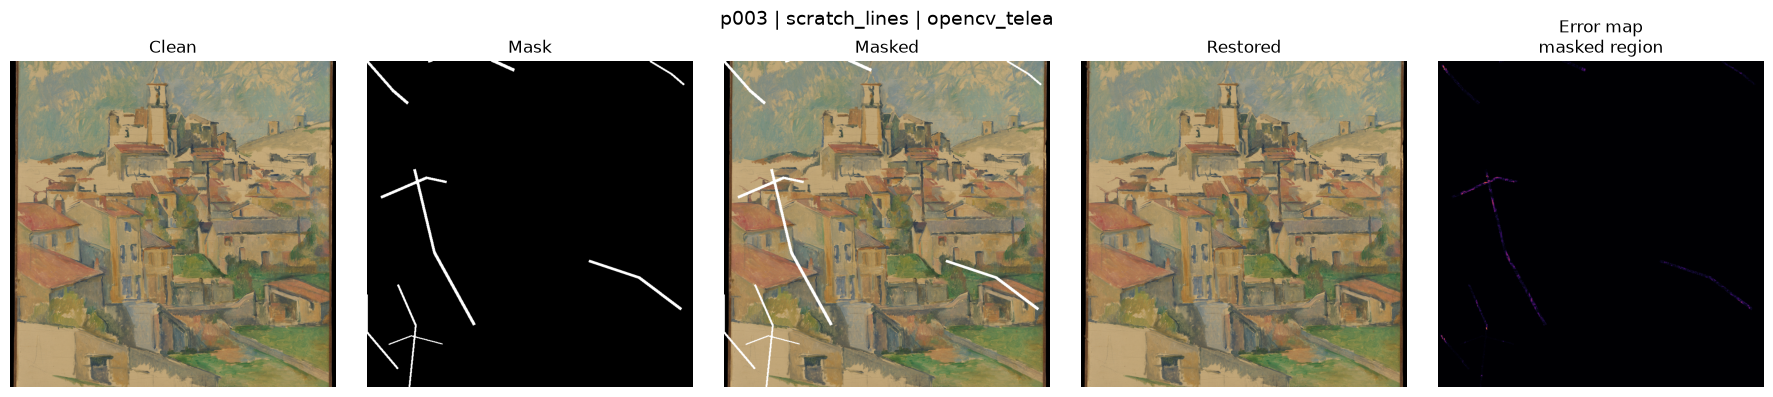

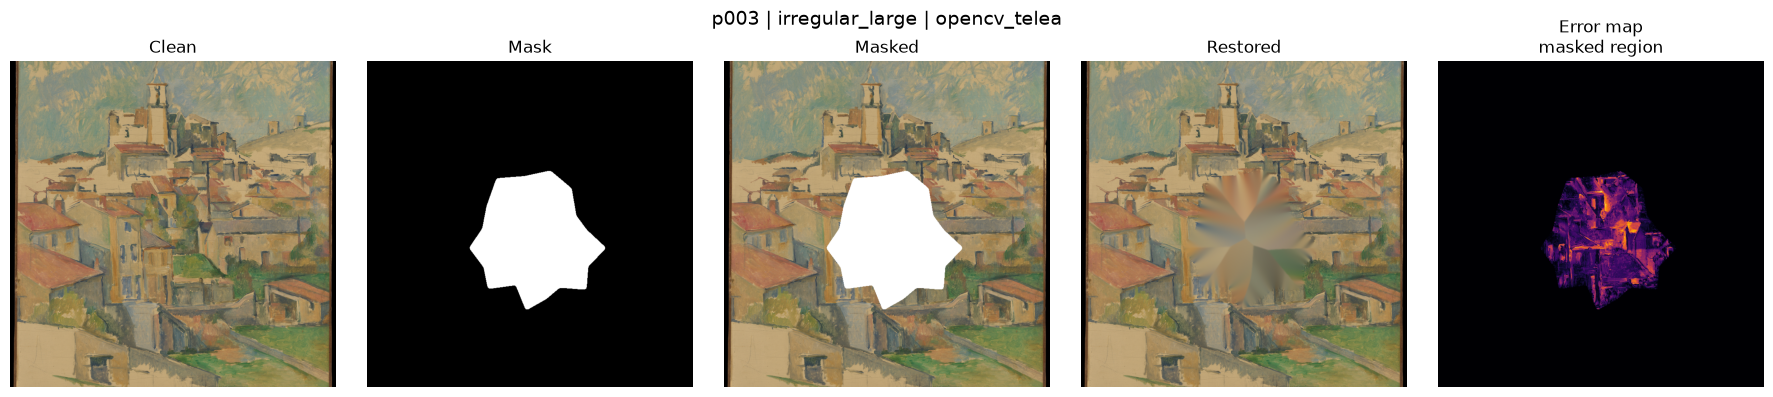

Comparison grid directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\comparison_grids


In [11]:
GRID_DIR = FIGURES_DIR / "comparison_grids"

create_comparison_grids(
    restoration_metadata=restoration_metadata,
    clean_dir=CLEAN_DIR,
    mask_dir=MASK_DIR,
    masked_dir=MASKED_DIR,
    restored_dir=RESTORED_DIR / "opencv_telea",
    grid_dir=GRID_DIR,
    show=True,
)

print("Comparison grid directory:", GRID_DIR)

## 4. Sanity checks

In [12]:
expected_difference_maps = len(restoration_metadata) * 2
actual_difference_maps = len(list(DIFF_MAP_DIR.glob("*.png")))

expected_grids = len(restoration_metadata)
actual_grids = len(list(GRID_DIR.glob("*.png")))

print(f"Expected difference maps: {expected_difference_maps}")
print(f"Actual difference maps:   {actual_difference_maps}")
print()
print(f"Expected comparison grids: {expected_grids}")
print(f"Actual comparison grids:   {actual_grids}")

assert actual_difference_maps >= expected_difference_maps
assert actual_grids >= expected_grids

Expected difference maps: 18
Actual difference maps:   18

Expected comparison grids: 9
Actual comparison grids:   9
